In [80]:
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_dir = os.getcwd()
#print("Diretório atual:", base_dir)

df = pd.read_csv("dataset_processado.csv")
print('\nDataset:\n',df.shape)

#x = df["Time since reaction (ms)"].values
#y = df["Filter (adc)"].values

#print('X:', x[:20])
#print('y:', y[:20])

df2 = df.copy()
df2["Time since reaction (ms)"] = df2["Time since reaction (ms)"]
df2["Filter (adc)"] = df2["Filter (adc)"]   

print('\nEstatistica Descritiva:\n\n',df2.describe())


Dataset:
 (506461, 4)

Estatistica Descritiva:

        Time since reaction (ms)   Filter (adc)
count             506461.000000  506461.000000
mean               11728.855114     479.158843
std                 9849.609872     732.149840
min                    0.000000       0.000000
25%                 1223.000000       4.000000
50%                10818.000000     128.000000
75%                20408.000000     623.000000
max                29998.000000    4091.000000


In [7]:
def detect_outlier_limite(df, col):
    # Calcula os limites do IQR
    Q1 = df[col].quantile(0.25) #calcula o quartil de 25% (valor abaixo do qual estão 25% dos dados ordenados)
    Q3 = df[col].quantile(0.75) #calcula o quartil de 75% (valor abaixo do qual estão 75% dos dados ordenados)
    IQR = Q3 - Q1 #calcula o índice interquartil

    limite_inferior = Q1 - 1.5 * IQR #calcula o o limite inferior
    limite_superior = Q3 + 1.5 * IQR #calcula o o limite superior
    return limite_inferior, limite_superior

In [15]:
def plot_boxplot_com_limites(col, limite_inferior, limite_superior):
    
    # Cria o boxplot com as linhas dos limites
    plt.figure(figsize=(6, 4)) #cria a figura largura e altura
    sns.boxplot( #chama o boxplot
    data= df, #define a base que será usada
    y=col, #define os dados do eixo y
    color='#2065ae', #cor do gráfico
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none') #parâmetros do ponto outlier
    )

    # Adiciona as linhas dos limites sem outliers
    plt.axhline(y=limite_inferior, color='blue', linestyle='--', label='Limite Inferior')
    plt.axhline(y=limite_superior, color='purple', linestyle='--', label='Limite Superior')

    # Ajustes finais
    plt.title(f'Boxplot de \n{col}') #adiciona o título
    plt.legend() #adiciona a legenda
    plt.tight_layout()#ajusta automaticamente o espaçamento entre os elementos do gráfico
    plt.show() #mostra o gráfico

### Checar outliers

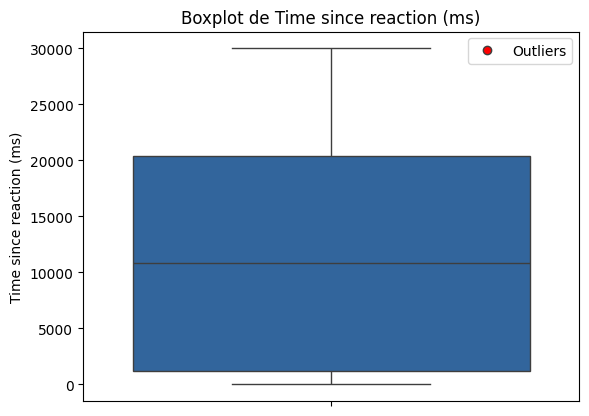

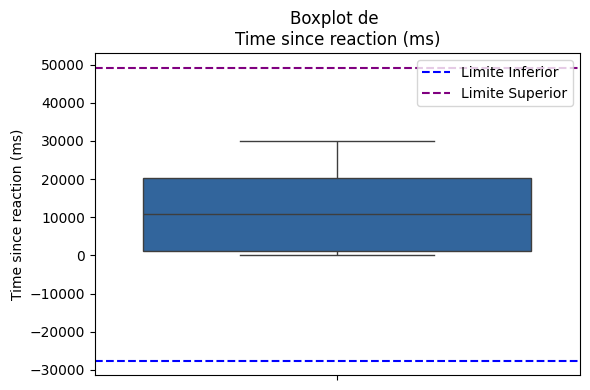

In [26]:
plt.title('Boxplot de Time since reaction (ms)') #adiciona o título
sns.boxplot(data=df, y='Time since reaction (ms)', color='#2065ae', flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none', label='Outliers' ))

inferior, superior = detect_outlier_limite(df, 'Time since reaction (ms)')
plot_boxplot_com_limites('Time since reaction (ms)', inferior, superior)

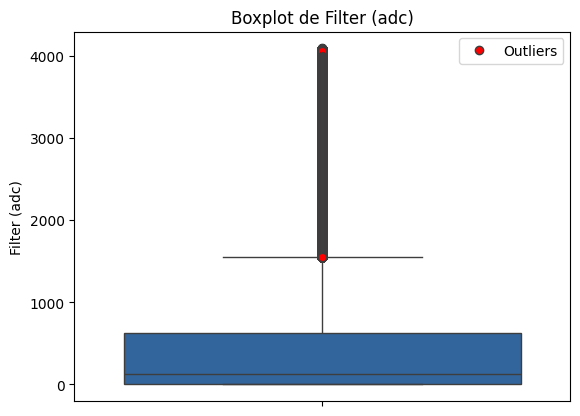

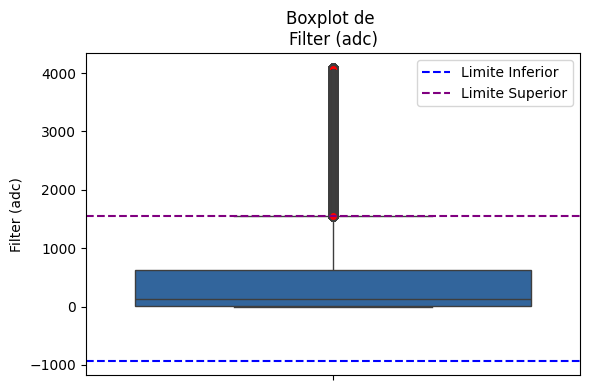

In [28]:
plt.title('Boxplot de Filter (adc)') #adiciona o título
sns.boxplot(data=df, y='Filter (adc)', color='#2065ae', flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none', label='Outliers' ))

inferior, superior = detect_outlier_limite(df, 'Filter (adc)')
plot_boxplot_com_limites('Filter (adc)', inferior, superior)

### Remover valores extremos / outliers

In [69]:
def remover_outliers(df):
    df_sem_outliers = df.copy()
    colunas = df_sem_outliers.columns.tolist()

    for col in colunas:
        inferior, superior = detect_outlier_limite(df_sem_outliers, col)
        df_sem_outliers = df_sem_outliers[
        (df_sem_outliers[col] >= inferior) &
        (df_sem_outliers[col] <= superior)
    ]
    return df_sem_outliers    

In [71]:
colunas = ['Time since reaction (ms)', 'Filter (adc)']
df_sem_outliers = df[colunas].copy()
df_sem_outliers.shape

(506461, 2)

In [73]:
df_sem_outliers = remover_outliers(df_sem_outliers)

In [74]:
df_sem_outliers.shape

(456558, 2)

### Estatistica Descriva sem outliers

In [76]:
df_sem_outliers.describe()

,Time since reaction (ms),Filter (adc)
count,456558.000000,456558.000000
mean,12498.266494,278.921627
std,10033.339097,381.762677
min,0.000000,0.000000
25%,288.000000,4.000000
50%,12655.500000,57.000000
75%,21353.000000,447.000000
max,29998.000000,1551.000000


In [ ]:
### Teste de novo dado na branch